# Forward Feature Selection for Dysgraphia Detection

## Overview

This notebook implements a **rigorously cross-validated Forward Feature Selection pipeline** using the CNN1DModel.

### Pipeline Phases:
1. **Phase 1**: Isolated single-feature testing — rank all 13 features by Validation AUC/Accuracy
2. **Phase 2**: Forward sequential addition — add features one-by-one if they improve Validation AUC by ≥ threshold
3. **Phase 3**: Final unseen evaluation — train on optimal subset, evaluate on **test set only once**

### Strict Data Isolation:
- **Train/Val**: Used for feature selection (Phase 1 & 2)
- **Test**: Touched **only** in Phase 3 for final evaluation

### Prerequisites:
1. Run `00_initialization.ipynb` first
2. Ensure `meta_df`, `Config`, and helpers are available

## 1. Setup and Imports

In [ ]:
# Load initialization (run 00_initialization.ipynb first, or use dysxai_init)
import os
import sys
for _d in [os.getcwd(), os.path.dirname(os.path.abspath("04_feature_selection.ipynb")),
           r"C:\Users\tiama\OneDrive\Desktop\period 2 courses\Reserach Project\DysXAI"]:
    if _d and os.path.exists(os.path.join(_d, "dysxai_init.py")):
        if _d not in sys.path:
            sys.path.insert(0, _d)
        break

if 'meta_df' not in globals():
    import dysxai_init
    for name in ['Config', 'load_raw_timeseries', 'load_and_process_timeseries', 'model_channel_names', 'discover_files_and_map_subjects', 'compute_derivatives',
                 'pad_truncate', 'MixedFeatureScaler', 'fit_scaler_on_train', 'fit_scaler_from_train_meta', 'apply_scaler',
                 'HandwritingDataset', 'subject_independent_split']:
        globals()[name] = getattr(dysxai_init, name)
    meta_df = dysxai_init.run_init(verbose=True)
    globals()['meta_df'] = meta_df
    print("Loaded from dysxai_init.py")
else:
    print("meta_df already available.")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt

print("Setup complete.")

Looking for files in: c:\Users\tiama\OneDrive\Desktop\Reserach Project\DysXAI\dysxai_tasks_split\task_5_hrackarstvo
Loaded 120 samples from 120 subjects
Loaded from dysxai_init.py
Setup complete.


## 2. CNN1D Model and Training Utilities

In [2]:
# Masked Global Average Pooling
class MaskedGlobalAvgPool1d(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x, lengths=None):
        if lengths is None:
            return x.mean(dim=-1)
        B, C, T = x.shape
        device = x.device
        mask = (torch.arange(T, device=device).unsqueeze(0) < lengths.unsqueeze(1))
        mask = mask.unsqueeze(1)
        x_masked = x * mask
        lengths_clamped = lengths.clamp(min=1).view(B, 1).float()
        return x_masked.sum(dim=-1) / lengths_clamped

# CNN1D Model
class CNN1DModel(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.gap = MaskedGlobalAvgPool1d()
        self.classifier = nn.Linear(256, num_classes)
    def forward(self, x, lengths=None):
        feat_maps = self.features(x)
        if lengths is not None:
            for _ in range(3):
                lengths = (lengths // 2).clamp(min=1)
        pooled = self.gap(feat_maps, lengths)
        logits = self.classifier(pooled)
        return logits, feat_maps

def compute_metrics(y_true, y_pred_probs):
    y_true = np.asarray(y_true)
    y_pred_probs = np.asarray(y_pred_probs)
    y_pred = (y_pred_probs >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    try:
        auc = roc_auc_score(y_true, y_pred_probs)
    except ValueError:
        auc = np.nan
    return {"accuracy": acc, "sensitivity": sensitivity, "specificity": specificity, "auc": auc, "confusion_matrix": cm}

def train_and_eval_val_only(train_loader, val_loader, model, num_epochs, class_weights, feature_indices, device, verbose=True):
    """
    Train model and evaluate ONLY on validation set. No test set touch.
    feature_indices: list of channel indices to slice from batch['x'] (e.g. [0, 3, 9])
    """
    model.to(device)
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)
    optimizer = Adam(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        model.train()
        train_losses = []
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False, disable=not verbose):
            x_full = batch["x"].to(device)
            x = x_full[:, feature_indices, :]
            y = batch["y"].to(device)
            lengths = batch["length"].to(device)
            optimizer.zero_grad()
            logits, _ = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                x_full = batch["x"].to(device)
                x = x_full[:, feature_indices, :]
                y = batch["y"].to(device)
                lengths = batch["length"].to(device)
                logits, _ = model(x, lengths)
                val_losses.append(criterion(logits, y).item())
                probs = torch.softmax(logits, dim=1)[:, 1]
                all_probs.append(probs.cpu().numpy())
                all_labels.append(y.cpu().numpy())
        avg_val_loss = float(np.mean(val_losses))
        all_probs = np.concatenate(all_probs)
        all_labels = np.concatenate(all_labels)
        val_metrics = compute_metrics(all_labels, all_probs)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        scheduler.step(avg_val_loss)

        if verbose and (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{num_epochs} - Val Loss: {avg_val_loss:.4f}, Val AUC: {val_metrics['auc']:.4f}")

        if Config.EARLY_STOPPING_ENABLED and patience_counter >= Config.EARLY_STOPPING_PATIENCE:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}. Best: epoch {best_epoch}")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            x_full = batch["x"].to(device)
            x = x_full[:, feature_indices, :]
            y = batch["y"].to(device)
            lengths = batch["length"].to(device)
            logits, _ = model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    final_val_metrics = compute_metrics(all_labels, all_probs)
    return model, final_val_metrics

print("CNN1D Model and training utilities defined.")

CNN1D Model and training utilities defined.


## 3. Prepare Data (3-Way Split)

**Strict isolation**: train_loader and val_loader for selection; test_loader untouched until Phase 3.

In [3]:
print("=" * 70)
print("PREPARING DATA (3-Way Split: Train / Val / Test)")
print("=" * 70)

train_meta, val_meta, test_meta = subject_independent_split(
    meta_df,
    train_ratio=Config.TRAIN_SUBJECT_RATIO,
    val_ratio=Config.VAL_SUBJECT_RATIO,
    random_state=Config.RANDOM_STATE
)

scaler = fit_scaler_from_train_meta(train_meta, Config.DATA_ROOT)

train_dataset = HandwritingDataset(train_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
val_dataset = HandwritingDataset(val_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)
test_dataset = HandwritingDataset(test_meta, Config.DATA_ROOT, scaler, Config.MAX_LEN, Config.USE_DERIVATIVES)

in_channels = train_dataset[0]['x'].shape[0]
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=0)

y_train = train_meta['label'].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train)

FEATURE_NAMES = model_channel_names()
assert len(FEATURE_NAMES) == in_channels

print(f"Train: {len(train_meta)} samples, Val: {len(val_meta)} samples, Test: {len(test_meta)} samples (UNTOUCHED until Phase 3)")
print(f"Input channels: {in_channels}")
print(f"Feature names: {FEATURE_NAMES}")
print("Data prepared.")

PREPARING DATA (3-Way Split: Train / Val / Test)
Train: 84 samples, Val: 18 samples, Test: 18 samples (UNTOUCHED until Phase 3)
Input channels: 12
Feature names: ['X', 'Y', 'Pressure', 'Azimuth', 'Altitude', 'Pen_Status', 'Velocity_X', 'Velocity_Y', 'Acceleration_X', 'Acceleration_Y', 'Jerk_X', 'Jerk_Y']
Data prepared.


## 4. Phase 1: Isolated Single-Feature Testing

Test each channel individually (12 after Time is dropped at load). Rank by Validation AUC (fallback: Accuracy).

In [4]:
print("=" * 70)
print("PHASE 1: ISOLATED SINGLE-FEATURE TESTING")
print("=" * 70)
print("Training CNN1DModel(in_channels=1) for each feature. Evaluation on VALIDATION only.\n")

phase1_results = []
for feat_idx in range(in_channels):
    name = FEATURE_NAMES[feat_idx] if feat_idx < len(FEATURE_NAMES) else f"Channel_{feat_idx}"
    print(f"Testing feature {feat_idx+1}/{in_channels}: {name}...", end=" ")

    model = CNN1DModel(in_channels=1)
    _, val_metrics = train_and_eval_val_only(
        train_loader, val_loader, model, Config.NUM_EPOCHS, class_weights,
        feature_indices=[feat_idx], device=Config.DEVICE, verbose=False
    )
    auc = val_metrics['auc'] if not np.isnan(val_metrics['auc']) else val_metrics['accuracy']
    acc = val_metrics['accuracy']
    phase1_results.append({
        'idx': feat_idx,
        'name': name,
        'val_auc': auc,
        'val_acc': acc
    })
    print(f"Val AUC: {auc:.4f}, Val Acc: {acc:.4f}")

# Rank by Validation AUC (primary), then Accuracy (tiebreaker)
phase1_results.sort(key=lambda r: (r['val_auc'], r['val_acc']), reverse=True)

print("\n" + "-" * 70)
print("RANKED FEATURES (Phase 1 - by Validation AUC/Accuracy):")
print("-" * 70)
for rank, r in enumerate(phase1_results, 1):
    print(f"  {rank:2d}. {r['name']:15s}  Val AUC: {r['val_auc']:.4f}  Val Acc: {r['val_acc']:.4f}")
print("=" * 70)

PHASE 1: ISOLATED SINGLE-FEATURE TESTING
Training CNN1DModel(in_channels=1) for each feature. Evaluation on VALIDATION only.

Testing feature 1/12: X... Val AUC: 0.5375, Val Acc: 0.6111
Testing feature 2/12: Y... Val AUC: 0.5875, Val Acc: 0.5556
Testing feature 3/12: Pressure... Val AUC: 0.3875, Val Acc: 0.5556
Testing feature 4/12: Azimuth... Val AUC: 0.6500, Val Acc: 0.6111
Testing feature 5/12: Altitude... Val AUC: 0.6500, Val Acc: 0.6667
Testing feature 6/12: Pen_Status... Val AUC: 0.6375, Val Acc: 0.6111
Testing feature 7/12: Velocity_X... Val AUC: 1.0000, Val Acc: 1.0000
Testing feature 8/12: Velocity_Y... Val AUC: 1.0000, Val Acc: 0.9444
Testing feature 9/12: Acceleration_X... Val AUC: 0.9250, Val Acc: 0.9444
Testing feature 10/12: Acceleration_Y... Val AUC: 0.8750, Val Acc: 0.9444
Testing feature 11/12: Jerk_X... Val AUC: 0.8875, Val Acc: 0.9444
Testing feature 12/12: Jerk_Y... Val AUC: 0.9375, Val Acc: 0.9444

-------------------------------------------------------------------

## 5. Phase 2: Forward Sequential Addition

Start with the top-ranked feature. Add features one-by-one. Keep only if Validation AUC improves by ≥ threshold.

In [5]:
# PHASE 2 (ALT): Forward Sequential Addition EXCLUDING 'Time'

print("=" * 70)
print("PHASE 2 (ALT): FORWARD SEQUENTIAL ADDITION (excluding 'Time')")
print("=" * 70)
print(f"Selection rule: Keep feature if Val AUC improves by >= {AUC_IMPROVEMENT_THRESHOLD}\n")

# 1) Build a ranked list WITHOUT 'Time'
phase1_no_time = [r for r in phase1_results if r['name'] != 'Time']

if not phase1_no_time:
    raise ValueError("No features left after excluding 'Time' from Phase 1 results.")

ranked_indices_nt = [r['idx'] for r in phase1_no_time]
ranked_names_nt   = [r['name'] for r in phase1_no_time]

# 2) Initialize with the best non-Time feature
selected_indices_no_time = [ranked_indices_nt[0]]
selected_names_no_time   = [ranked_names_nt[0]]

# Option: recompute current AUC for the starting subset (1 feature) for clarity
model = CNN1DModel(in_channels=1)
_, val_metrics = train_and_eval_val_only(
    train_loader, val_loader, model, Config.NUM_EPOCHS, class_weights,
    feature_indices=selected_indices_no_time,
    device=Config.DEVICE,
    verbose=False,
)
current_auc_no_time = val_metrics['auc'] if not np.isnan(val_metrics['auc']) else val_metrics['accuracy']

print(
    f"Starting (excluding 'Time') with feature: {selected_names_no_time[0]} "
    f"(Val AUC: {current_auc_no_time:.4f})"
)
print()

# 3) Forward addition over remaining non-Time features
for i in range(1, len(ranked_indices_nt)):
    candidate_idx  = ranked_indices_nt[i]
    candidate_name = ranked_names_nt[i]

    trial_subset = selected_indices_no_time + [candidate_idx]

    print(f"Testing addition of feature '{candidate_name}'...", end=" ")
    model = CNN1DModel(in_channels=len(trial_subset))
    _, val_metrics = train_and_eval_val_only(
        train_loader, val_loader, model, Config.NUM_EPOCHS, class_weights,
        feature_indices=trial_subset,
        device=Config.DEVICE,
        verbose=False,
    )

    new_auc = val_metrics['auc'] if not np.isnan(val_metrics['auc']) else val_metrics['accuracy']
    improvement = new_auc - current_auc_no_time

    if improvement >= AUC_IMPROVEMENT_THRESHOLD:
        selected_indices_no_time.append(candidate_idx)
        selected_names_no_time.append(candidate_name)
        print(f"Validation AUC improved from {current_auc_no_time:.4f} to {new_auc:.4f} "
              f"(+{improvement:.4f}). Keeping feature.")
        current_auc_no_time = new_auc
    else:
        print(f"Validation AUC {new_auc:.4f} (improvement {improvement:+.4f} "
              f"< {AUC_IMPROVEMENT_THRESHOLD}). Discarding feature.")

print("\n" + "-" * 70)
print("OPTIMAL FEATURE SUBSET (Phase 2 ALT, excluding 'Time'):")
print("-" * 70)
print(f"  Selected: {selected_names_no_time}")
print(f"  Indices: {selected_indices_no_time}")
print(f"  Final Val AUC (excluding 'Time'): {current_auc_no_time:.4f}")
print("=" * 70)

PHASE 2 (ALT): FORWARD SEQUENTIAL ADDITION (excluding 'Time')


NameError: name 'AUC_IMPROVEMENT_THRESHOLD' is not defined

In [ ]:
AUC_IMPROVEMENT_THRESHOLD = 0.01  # Minimum improvement to keep a feature

print("=" * 70)
print("PHASE 2: FORWARD SEQUENTIAL ADDITION")
print("=" * 70)
print(f"Selection rule: Keep feature if Val AUC improves by >= {AUC_IMPROVEMENT_THRESHOLD}\n")

ranked_indices = [r['idx'] for r in phase1_results]
ranked_names = [r['name'] for r in phase1_results]

selected_indices = [ranked_indices[0]]
selected_names = [ranked_names[0]]
current_auc = phase1_results[0]['val_auc']

print(f"Starting with top feature: {selected_names[0]} (Val AUC: {current_auc:.4f})")
print()

for i in range(1, len(ranked_indices)):
    candidate_idx = ranked_indices[i]
    candidate_name = ranked_names[i]
    trial_subset = selected_indices + [candidate_idx]

    print(f"Testing addition of feature '{candidate_name}'...", end=" ")
    model = CNN1DModel(in_channels=len(trial_subset))
    _, val_metrics = train_and_eval_val_only(
        train_loader, val_loader, model, Config.NUM_EPOCHS, class_weights,
        feature_indices=trial_subset, device=Config.DEVICE, verbose=False
    )
    new_auc = val_metrics['auc'] if not np.isnan(val_metrics['auc']) else val_metrics['accuracy']
    improvement = new_auc - current_auc

    if improvement >= AUC_IMPROVEMENT_THRESHOLD:
        selected_indices.append(candidate_idx)
        selected_names.append(candidate_name)
        print(f"Validation AUC improved from {current_auc:.4f} to {new_auc:.4f} (+{improvement:.4f}). Keeping feature.")
        current_auc = new_auc
    else:
        print(f"Validation AUC {new_auc:.4f} (improvement {improvement:+.4f} < {AUC_IMPROVEMENT_THRESHOLD}). Discarding feature.")

print("\n" + "-" * 70)
print("OPTIMAL FEATURE SUBSET (Phase 2):")
print("-" * 70)
print(f"  Selected: {selected_names}")
print(f"  Indices: {selected_indices}")
print(f"  Final Val AUC: {current_auc:.4f}")
print("=" * 70)

PHASE 2: FORWARD SEQUENTIAL ADDITION
Selection rule: Keep feature if Val AUC improves by >= 0.01

Starting with top feature: Time (Val AUC: 1.0000)

Testing addition of feature 'Velocity_X'... Validation AUC 0.9625 (improvement -0.0375 < 0.01). Discarding feature.
Testing addition of feature 'Acceleration_Y'... Validation AUC 0.9750 (improvement -0.0250 < 0.01). Discarding feature.
Testing addition of feature 'Acceleration_X'... Validation AUC 0.9500 (improvement -0.0500 < 0.01). Discarding feature.
Testing addition of feature 'Velocity_Y'... Validation AUC 1.0000 (improvement +0.0000 < 0.01). Discarding feature.
Testing addition of feature 'Jerk_X'... Validation AUC 0.9500 (improvement -0.0500 < 0.01). Discarding feature.
Testing addition of feature 'Jerk_Y'... Validation AUC 0.9750 (improvement -0.0250 < 0.01). Discarding feature.
Testing addition of feature 'Azimuth'... Validation AUC 0.9750 (improvement -0.0250 < 0.01). Discarding feature.
Testing addition of feature 'Pressure'... 

## 6. Phase 3: Final Unseen Evaluation

Train one final model on the optimal subset. Evaluate **only now** on the unseen test set.

In [ ]:
def train_and_eval_on_test(train_loader, val_loader, test_loader, model, num_epochs, class_weights, feature_indices, device):
    """Train with val early-stop, then evaluate on test (single touch)."""
    model, _ = train_and_eval_val_only(train_loader, val_loader, model, num_epochs, class_weights, feature_indices, device, verbose=True)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            x_full = batch["x"].to(device)
            x = x_full[:, feature_indices, :]
            y = batch["y"].to(device)
            lengths = batch["length"].to(device)
            logits, _ = model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    return compute_metrics(all_labels, all_probs)

print("=" * 70)
print("PHASE 3: FINAL UNSEEN EVALUATION")
print("=" * 70)
print("Training final model on optimal subset. Evaluating on TEST set (first and only touch).\n")

print("Training BASELINE model (all features)...")
baseline_model = CNN1DModel(in_channels=in_channels)
baseline_test_metrics = train_and_eval_on_test(
    train_loader, val_loader, test_loader, baseline_model, Config.NUM_EPOCHS, class_weights,
    feature_indices=list(range(in_channels)), device=Config.DEVICE
)

print("\nTraining OPTIMAL SUBSET model...")
optimal_model = CNN1DModel(in_channels=len(selected_indices))
optimal_test_metrics = train_and_eval_on_test(
    train_loader, val_loader, test_loader, optimal_model, Config.NUM_EPOCHS, class_weights,
    feature_indices=selected_indices, device=Config.DEVICE
)

print("\n" + "=" * 70)
print("FINAL COMPARATIVE METRICS (Test Set - Unseen)")
print("=" * 70)
print(f"\n{'Metric':<15} {'Baseline (All 13)':<20} {'Optimal Subset':<20}")
print("-" * 55)
print(f"{'Accuracy':<15} {baseline_test_metrics['accuracy']:<20.4f} {optimal_test_metrics['accuracy']:<20.4f}")
print(f"{'Sensitivity':<15} {baseline_test_metrics['sensitivity']:<20.4f} {optimal_test_metrics['sensitivity']:<20.4f}")
print(f"{'Specificity':<15} {baseline_test_metrics['specificity']:<20.4f} {optimal_test_metrics['specificity']:<20.4f}")
print(f"{'AUC':<15} {baseline_test_metrics['auc']:<20.4f} {optimal_test_metrics['auc']:<20.4f}")
print(f"\nOptimal subset features: {selected_names}")
print("=" * 70)

PHASE 3: FINAL UNSEEN EVALUATION
Training final model on optimal subset. Evaluating on TEST set (first and only touch).

Training BASELINE model (all features)...


  Epoch 5/50 - Val Loss: 0.2825, Val AUC: 0.8875


  Epoch 10/50 - Val Loss: 0.2069, Val AUC: 0.9250


  Early stopping at epoch 12. Best: epoch 7

Training OPTIMAL SUBSET model...


  Epoch 5/50 - Val Loss: 0.2218, Val AUC: 1.0000


  Epoch 10/50 - Val Loss: 0.2017, Val AUC: 1.0000


  Epoch 15/50 - Val Loss: 0.1432, Val AUC: 1.0000


  Epoch 20/50 - Val Loss: 0.1815, Val AUC: 1.0000


  Early stopping at epoch 21. Best: epoch 16

FINAL COMPARATIVE METRICS (Test Set - Unseen)

Metric          Baseline (All 13)    Optimal Subset      
-------------------------------------------------------
Accuracy        0.8889               0.8889              
Sensitivity     0.7778               0.7778              
Specificity     1.0000               1.0000              
AUC             0.9753               0.8148              

Optimal subset features: ['Time']


## 7. Final Confusion Matrix

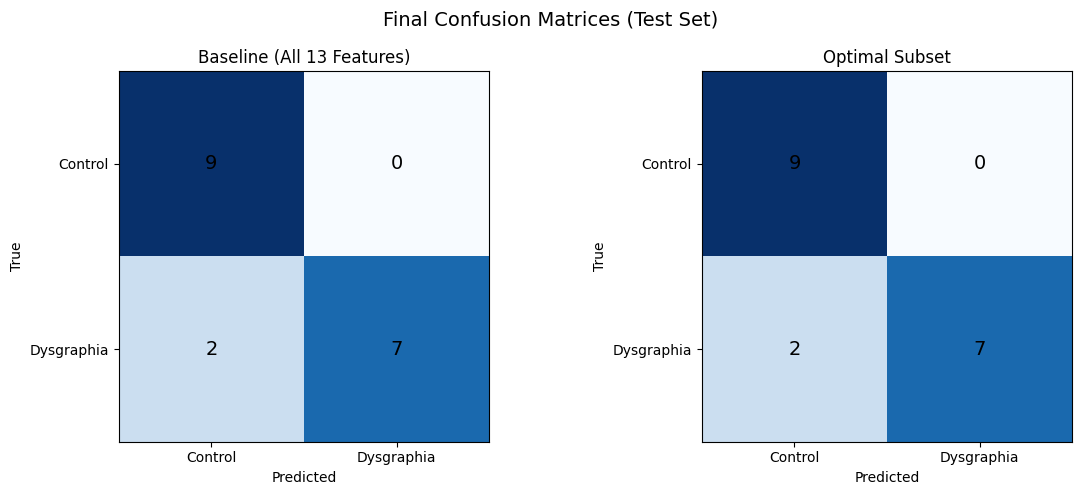

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metrics, title in [(axes[0], baseline_test_metrics, 'Baseline (All 13 channels)'),
                           (axes[1], optimal_test_metrics, 'Optimal Subset')]:
    cm = metrics['confusion_matrix']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Control', 'Dysgraphia'])
    ax.set_yticklabels(['Control', 'Dysgraphia'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14)

plt.suptitle('Final Confusion Matrices (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()